# **Projeto de Graduação em Computação II [2026-Q1]**

Universidade Federal do ABC

Orientador Carlos da Silva dos Santos

### **EQUIPE**

---

Caio Cardoso Dos Santos - RA: 11202021632

Victor Ravazio de Lima - RA: 11201920941

### **IMPLEMENTAÇÃO**
---

In [1]:
# modulo para importar dataset a partir de um link
!pip install gdown

In [2]:
#Bibliotecas
import pandas as pd
import numpy as np
from google.colab import files
import gdown
import matplotlib.pyplot as plt
import random
import seaborn as sns

# **Importando datasets temáticos classificados e homologados**

In [3]:
# baixando datasets para o collab
import gdown

file_class_aborto = "12XHDy0MqxEr2TixTiDO8uihO_GhmPfr-" #Convergencias aborto
file_class_cloroquina = "1j7c7ROl8QuDkWQ1riHhbYP-FWnOtO5jn" #convergencias cloroquina
file_class_contas_suspensas = "1b2mcNOXECl0ZXegRHENE_npxdnyk3grR" #convergencias contas suspensas
file_class_mandetta = "1WWTmJRutmk50HRzsbWFHeb-y7nzMCIAO" #convergencias mandetta

url_1 = f"https://drive.google.com/uc?id={file_class_aborto}"
url_2 = f"https://drive.google.com/uc?id={file_class_cloroquina}"
url_3 = f"https://drive.google.com/uc?id={file_class_contas_suspensas}"
url_4 = f"https://drive.google.com/uc?id={file_class_mandetta}"


gdown.download(url_1, "aborto_homologado.csv", quiet=False)
gdown.download(url_2, "cloroquina_homologado.csv", quiet=False)
gdown.download(url_3, "contas_suspensas_homologado.csv", quiet=False)
gdown.download(url_4, "mandetta_homologado.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=12XHDy0MqxEr2TixTiDO8uihO_GhmPfr-
To: /content/aborto_homologado.csv
100%|██████████| 42.6k/42.6k [00:00<00:00, 45.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1j7c7ROl8QuDkWQ1riHhbYP-FWnOtO5jn
To: /content/cloroquina_homologado.csv
100%|██████████| 47.8k/47.8k [00:00<00:00, 18.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1b2mcNOXECl0ZXegRHENE_npxdnyk3grR
To: /content/contas_suspensas_homologado.csv
100%|██████████| 46.5k/46.5k [00:00<00:00, 56.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1WWTmJRutmk50HRzsbWFHeb-y7nzMCIAO
To: /content/mandetta_homologado.csv
100%|██████████| 45.9k/45.9k [00:00<00:00, 10.4MB/s]


'mandetta_homologado.csv'

In [4]:
#Carregando e processando os datasets tematicos
def carregar_dataset(arquivo, tema):
    df = pd.read_csv(arquivo) #carregando o df
    df['Conflict'] = df['Conflict'].astype(int) #convertendo para int
    df['Tema'] = tema #registrando o tema
    return df[['tweet_1', 'tweet_2', 'Tema', 'Class', 'P(NoConflict)', 'P(Conflict)', 'Conflict']] #ordenando as colunas

df_aborto = carregar_dataset("aborto_homologado.csv", "Aborto")
df_cloroquina = carregar_dataset("cloroquina_homologado.csv", "Cloroquina")
df_contas_suspensas = carregar_dataset("contas_suspensas_homologado.csv","Contas suspensas")
df_mandetta = carregar_dataset("mandetta_homologado.csv", "Mandetta")

#**Análise exploratória dos dataset temáticos:**

In [5]:
#NUMERO TOTAL DE INSTANCIAS HOMOLOGADAS
print("NUMERO DE INSTANCIAS HOMOLOGADAS:")
print("Aborto: ", df_aborto.shape)
print("Cloroquina: ", df_cloroquina.shape)
print("Contas suspensas: ", df_contas_suspensas.shape)
print("Mandetta: ", df_mandetta.shape)
print("Total: ", df_aborto.shape[0] + df_cloroquina.shape[0] + df_contas_suspensas.shape[0] + df_mandetta.shape[0])

NUMERO DE INSTANCIAS HOMOLOGADAS:
Aborto:  (127, 7)
Cloroquina:  (131, 7)
Contas suspensas:  (133, 7)
Mandetta:  (133, 7)
Total:  524


In [6]:
#CLASSIFICAÇÕES POR CLASSES
print("CLASSIFICAÇÕES POR CLASSES:")
print("Aborto:")
print("Conflito:", df_aborto[df_aborto['Conflict'] == 1].shape[0])
print("Não conflito:", df_aborto[df_aborto['Conflict'] == 0].shape[0])
print("indeterminado:", df_aborto[df_aborto['Conflict'] == -1].shape[0])
print()
print("Cloroquina:")
print("Conflito:", df_cloroquina[df_cloroquina['Conflict'] == 1].shape[0])
print("Não conflito:", df_cloroquina[df_cloroquina['Conflict'] == 0].shape[0])
print("indeterminado:", df_cloroquina[df_cloroquina['Conflict'] == -1].shape[0])
print()
print("Contas suspensas:")
print("Conflito:", df_contas_suspensas[df_contas_suspensas['Conflict'] == 1].shape[0])
print("Não conflito:", df_contas_suspensas[df_contas_suspensas['Conflict'] == 0].shape[0])
print("indeterminado:", df_contas_suspensas[df_contas_suspensas['Conflict'] == -1].shape[0])
print()
print("Mandetta:")
print("Conflito:", df_mandetta[df_mandetta['Conflict'] == 1].shape[0])
print("Não conflito:", df_mandetta[df_mandetta['Conflict'] == 0].shape[0])
print("indeterminado:", df_mandetta[df_mandetta['Conflict'] == -1].shape[0])


CLASSIFICAÇÕES POR CLASSES:
Aborto:
Conflito: 54
Não conflito: 69
indeterminado: 4

Cloroquina:
Conflito: 35
Não conflito: 95
indeterminado: 1

Contas suspensas:
Conflito: 26
Não conflito: 106
indeterminado: 1

Mandetta:
Conflito: 38
Não conflito: 94
indeterminado: 1


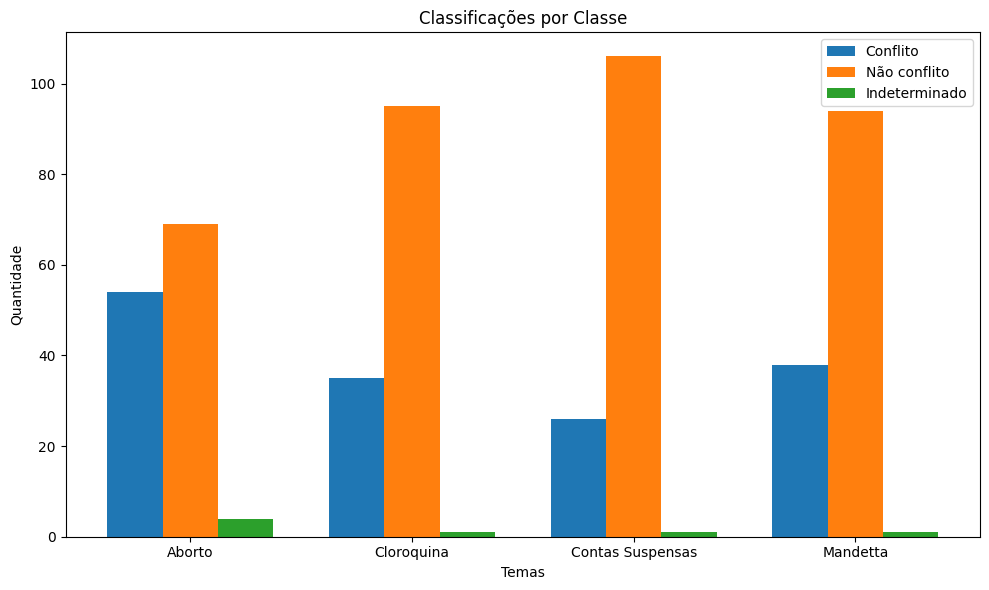

In [7]:
#GRAFICOS
#classificações por classes

#Organizando os dados
temas = ["Aborto", "Cloroquina", "Contas Suspensas", "Mandetta"]

conflito = [
    df_aborto[df_aborto['Conflict'] == 1].shape[0],
    df_cloroquina[df_cloroquina['Conflict'] == 1].shape[0],
    df_contas_suspensas[df_contas_suspensas['Conflict'] == 1].shape[0],
    df_mandetta[df_mandetta['Conflict'] == 1].shape[0]
]

nao_conflito = [
    df_aborto[df_aborto['Conflict'] == 0].shape[0],
    df_cloroquina[df_cloroquina['Conflict'] == 0].shape[0],
    df_contas_suspensas[df_contas_suspensas['Conflict'] == 0].shape[0],
    df_mandetta[df_mandetta['Conflict'] == 0].shape[0]
]

indeterminado = [
    df_aborto[df_aborto['Conflict'] == -1].shape[0],
    df_cloroquina[df_cloroquina['Conflict'] == -1].shape[0],
    df_contas_suspensas[df_contas_suspensas['Conflict'] == -1].shape[0],
    df_mandetta[df_mandetta['Conflict'] == -1].shape[0]
]

#posicionando barras

x = np.arange(len(temas)) #cria vetor [0,1,2,..,(len(temas))]

largura = 0.25

#desenhando grafico

plt.figure(figsize=(10, 6))

plt.bar(x - largura, conflito, width=largura, label="Conflito")
plt.bar(x, nao_conflito, width=largura, label="Não conflito")
plt.bar(x + largura, indeterminado, width=largura, label="Indeterminado")


plt.xticks(x, temas)

plt.title("Classificações por Classe")
plt.xlabel("Temas")
plt.ylabel("Quantidade")

plt.legend() #cria a caixinha de legenda

plt.tight_layout() #ajusta resolução para não cortar texto

plt.show()

#**Dataset final**

In [8]:
#CONCATENANDO DATASETS TEMÁTICOS
df_final = pd.concat([df_aborto, df_cloroquina, df_contas_suspensas, df_mandetta], ignore_index=True, axis = 0)
df_final.shape

(524, 7)

In [9]:
df_final

,tweet_1,tweet_2,Tema,Class,P(NoConflict),P(Conflict),Conflict
0,"#AbortoNao caramba, eu entrando na TAG e vend...",Até 3 meses #AbortoSim,Aborto,0,0.437456,0.562544,0
1,"#AbortoNAO, STF usurpador de atribuições.","Caros esquerdolóides imb3cis, respondam a este...",Aborto,0,0.497015,0.502985,0
2,Argumentos que usam para serem contra o aborto...,#AbortoNao aborto é coisa do diabo,Aborto,0,0.590572,0.409428,1
3,"، ⌕ ─ vamos fazer um acordo, só opina sob...",Em tempos de tantas dificuldades vem a tona a ...,Aborto,0,0.426560,0.573439,1
4,Aborte a sua ignorância e não pessoas ! #Abor...,é contra aborto mas é a favor da pena? pfv né....,Aborto,0,0.465280,0.534720,1
...,...,...,...,...,...,...,...
519,Desejo ao Dr. Nelson Teich novo Ministro da Sa...,eu tava no cagaço do dia que eu ia ler essa no...,Mandetta,0,0.404341,0.595659,0
520,Moro: técnico; Guedes: técnico; Pontes: técnic...,Mandetta não é técnico por qual critério? No m...,Mandetta,1,0.570573,0.429427,1
521,Mandetta fica como prova didática de que nem p...,Definição mais cirúrgica que li sobre o papel ...,Mandetta,1,0.528528,0.471472,0
522,No meio de uma pandemia mundial o bonitão demi...,Bolsonaro é um rato oportunista. Demitiu Mande...,Mandetta,0,0.490989,0.509011,0


In [10]:
#ANALISE EXPLORATÓRIA - DATASET FINAL
print("CLASSIFICAÇÕES POR CLASSES:")
print("conflito:", df_final[df_final['Conflict'] == 1].shape[0])
print("não conflito:", df_final[df_final['Conflict'] == 0].shape[0])
print("indeterminado:", df_final[df_final['Conflict'] == -1].shape[0])

CLASSIFICAÇÕES POR CLASSES:
conflito: 153
não conflito: 364
indeterminado: 7


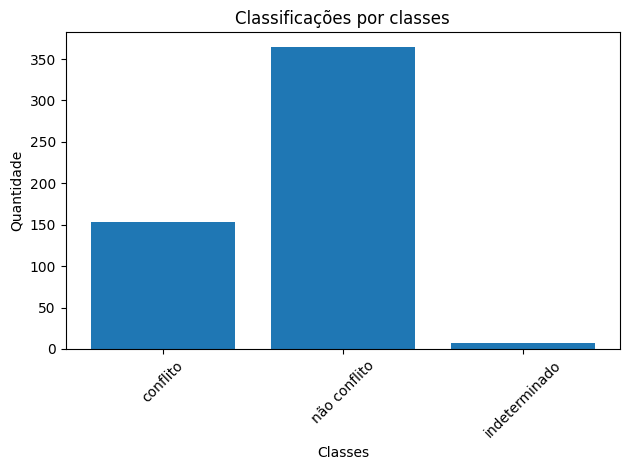

In [11]:
#GRAFICOS
#classificações por classes (conflito e não conflito)
conflitos = df_final[df_final['Conflict'] == 1].shape[0]
nao_conflitos = df_final[df_final['Conflict'] == 0].shape[0]
indeterminados = df_final[df_final['Conflict'] == -1].shape[0]

labels = ["conflito","não conflito", "indeterminado"]
values = [conflitos, nao_conflitos, indeterminados]
plt.figure()
plt.bar(labels, values)
plt.title("Classificações por classes")
plt.xlabel("Classes")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#classificações por estrutura de tweet (reply, quote, original)

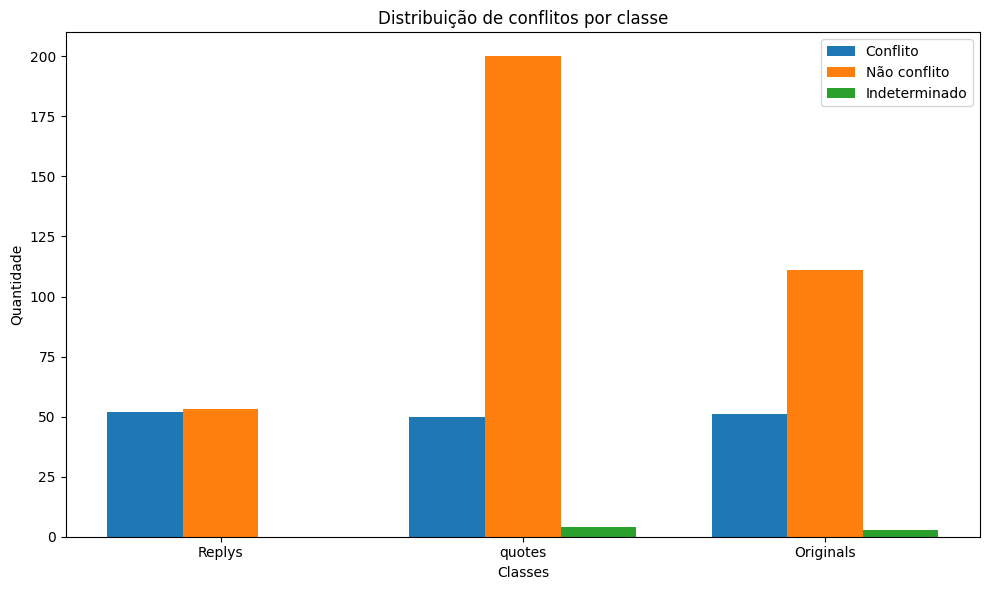

In [12]:
#Distribuição de conflitos por classes

#Separando as classes
reply = df_final[df_final['Class'] == 1]
quote = df_final[df_final['Class'] == 2]
original = df_final[df_final['Class'] == 0]

#Registando as contagens de classificações por estruturas
classes = ['Replys', 'quotes', 'Originals']

conflitos = [
    reply[reply['Conflict'] == 1].shape[0],
    quote[quote['Conflict'] == 1].shape[0],
    original[original['Conflict'] == 1].shape[0]
]

nao_conflitos = [
    reply[reply['Conflict'] == 0].shape[0],
    quote[quote['Conflict'] == 0].shape[0],
    original[original['Conflict'] == 0].shape[0]
]

indeterminados = [
    reply[reply['Conflict'] == -1].shape[0],
    quote[quote['Conflict'] == -1].shape[0],
    original[original['Conflict'] == -1].shape[0]
]



# Posição das barras

x = np.arange(len(classes))

largura = 0.25

#desenhando o grafico

plt.figure(figsize=(10,6))

plt.bar(x - largura, conflitos,
        width=largura,
        label='Conflito')

plt.bar(x, nao_conflitos,
        width=largura,
        label='Não conflito')

plt.bar(x + largura, indeterminados,
        width=largura,
        label='Indeterminado')

plt.xticks(x, classes)

plt.xlabel("Classes")
plt.ylabel("Quantidade")

plt.title("Distribuição de conflitos por classe")

plt.legend()

plt.tight_layout()

plt.show()

In [13]:
df_final = df_final.drop(columns=['P(NoConflict)', 'P(Conflict)'])
df_final

,tweet_1,tweet_2,Tema,Class,Conflict
0,"#AbortoNao caramba, eu entrando na TAG e vend...",Até 3 meses #AbortoSim,Aborto,0,0
1,"#AbortoNAO, STF usurpador de atribuições.","Caros esquerdolóides imb3cis, respondam a este...",Aborto,0,0
2,Argumentos que usam para serem contra o aborto...,#AbortoNao aborto é coisa do diabo,Aborto,0,1
3,"، ⌕ ─ vamos fazer um acordo, só opina sob...",Em tempos de tantas dificuldades vem a tona a ...,Aborto,0,1
4,Aborte a sua ignorância e não pessoas ! #Abor...,é contra aborto mas é a favor da pena? pfv né....,Aborto,0,1
...,...,...,...,...,...
519,Desejo ao Dr. Nelson Teich novo Ministro da Sa...,eu tava no cagaço do dia que eu ia ler essa no...,Mandetta,0,0
520,Moro: técnico; Guedes: técnico; Pontes: técnic...,Mandetta não é técnico por qual critério? No m...,Mandetta,1,1
521,Mandetta fica como prova didática de que nem p...,Definição mais cirúrgica que li sobre o papel ...,Mandetta,1,0
522,No meio de uma pandemia mundial o bonitão demi...,Bolsonaro é um rato oportunista. Demitiu Mande...,Mandetta,0,0


In [14]:
df_final.to_csv("dataset_conflitos_exploratorio.csv", index=False, encoding="utf-8")
files.download("dataset_conflitos_exploratorio.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>